In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [3]:
df = pd.read_csv('train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
40918,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


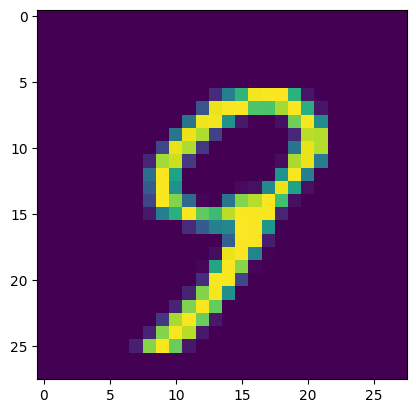

In [6]:
plt.imshow(df.iloc[40918,1:].values.reshape(28,28))

In [7]:
X = df.iloc[:,1:]
y = df.iloc[:,0]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
print(X_train.shape)
print(X_test.shape)

(33600, 784)
(8400, 784)


In [9]:
knn = KNeighborsClassifier()
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
import time 
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

17.195369958877563


In [11]:
accuracy_score(y_test,y_pred)

0.9648809523809524

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
#PCA
pca = PCA(n_components=200)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [14]:
print(X_train_trf.shape)

(33600, 200)


In [15]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [16]:
start = time.time()
y_pred = knn.predict(X_test_trf)
print(time.time() - start)

8.0520179271698


In [17]:
accuracy_score(y_test,y_pred)

0.9507142857142857

In [19]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

components = [10, 20, 30, 40, 50, 75, 100, 125, 150, 200, 250, 300, 350, 400, 500, 600, 700]

best_accuracy = 0
best_n_components = 0

print("n_components\tAccuracy")

for i in components:
    # Select first i principal components
    X_train_trf = X_train_pca[:, :i]
    X_test_trf = X_test_pca[:, :i]

    # Train KNN
    knn = KNeighborsClassifier()
    knn.fit(X_train_trf, y_train)

    # Predict and calculate accuracy
    y_pred = knn.predict(X_test_trf)
    acc = accuracy_score(y_test, y_pred)

    print(f"{i}\t\t{acc:.4f}")

    # Store the best result
    if acc > best_accuracy:
        best_accuracy = acc
        best_n_components = i

print("\n==============================")
print(f"Best PCA Components : {best_n_components}")
print(f"Best Accuracy       : {best_accuracy:.4f}")

n_components	Accuracy
10		0.9056
20		0.9443
30		0.9492
40		0.9529
50		0.9533
75		0.9550
100		0.9544
125		0.9532
150		0.9520
200		0.9507
250		0.9486
300		0.9468
350		0.9446
400		0.9437
500		0.9411
600		0.9396
700		0.9392

Best PCA Components : 75
Best Accuracy       : 0.9550


**Transforming to a 2D coordinate system**

In [20]:
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [21]:
X_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]], shape=(33600, 2))

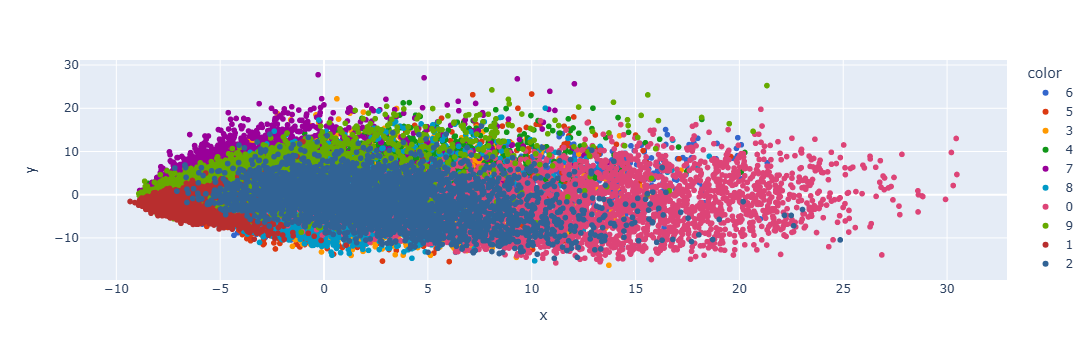

In [23]:
import plotly.express as px

y_train_trf = y_train.astype(str)
fig = px.scatter(x = X_train_trf[:,0],
                y = X_train_trf[:,1],
                color =y_train_trf,
                color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

# **Transforming in 3D**

In [24]:
pca = PCA(n_components = 3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [25]:
X_train_trf

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]], shape=(33600, 3))

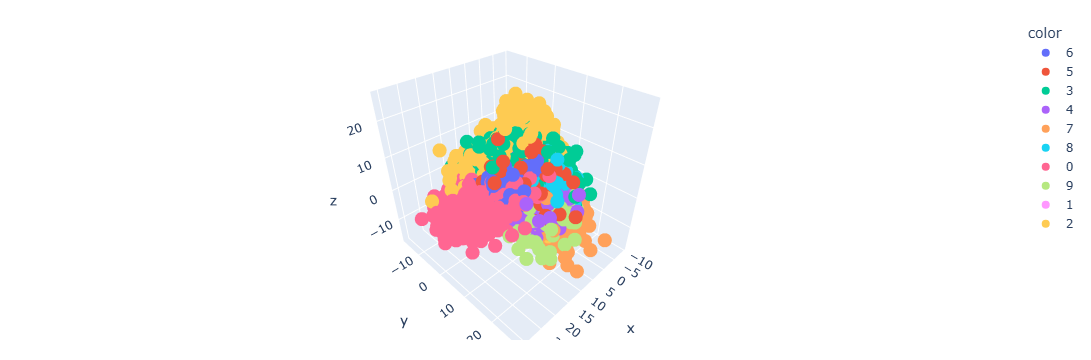

In [27]:
# y_train_trf = y_train.astype(str)
# fig = px.scatter_3d(df,x = X_train_trf[:,0],y=X_train_trf[:,1],z =X_train[:,2],color=y_train_trf)
# fig.update_layout(
#     margin=dict(l=20,r=20,t=20,b=20)
# )
# fig.show()

fig = px.scatter_3d(
    x=X_train_trf[:,0],
    y=X_train_trf[:,1],
    z=X_train_trf[:,2],
    color=y_train.astype(str)
)

fig.update_layout(margin=dict(l=20, r=20, t=20, b=20))
fig.show()

In [28]:
# Eigen Values
pca.explained_variance_

array([40.67111198, 29.17023401, 26.74459621])

In [29]:
# Eigen Vector
pca.components_

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(3, 784))

In [30]:
pca.components_.shape

(3, 784)

In [31]:
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])